<a href="https://colab.research.google.com/github/IsaganiI/CAHSI-Research/blob/main/rna_ctcf_gnn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch-geometric scikit-learn networkx matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.7 MB/s eta 0:00:00


In [3]:
import torch
from torch_geometric.data import HeteroData
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.utils import negative_sampling
from torch_geometric.nn import HeteroConv, SAGEConv
import torch.nn as nn
from sklearn.metrics import roc_auc_score


data = HeteroData()
data['rna'].x = torch.rand(100, 128)
data['ctcf'].x = torch.randn(50, 128)
edge_index = torch.tensor([
    [0,  1,  1,  2,  3,  4,  5,  6,  7,  8,
     9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
    [0,  5,  2,  3,  1,  2,  3,  4,  5,  6,
     7,  8,  9, 10, 11, 12, 13, 14, 15, 16]], dtype=torch.long)
print(data)

num_edges = edge_index.size(1)
perm = torch.randperm(num_edges)

train_size = int(0.8 * num_edges)
val_size   = int(0.1 * num_edges)

train_idx = perm[:train_size]
val_idx   = perm[train_size:train_size + val_size]
test_idx  = perm[train_size + val_size:]

import copy
train_data = copy.deepcopy(data)
val_data   = copy.deepcopy(data)
test_data  = copy.deepcopy(data)

train_data['rna','interacts','ctcf'].edge_index = edge_index[:, train_idx]
val_data['rna','interacts','ctcf'].edge_index   = edge_index[:, val_idx]
test_data['rna','interacts','ctcf'].edge_index  = edge_index[:, test_idx]

class GNNModel(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.rna_lin  = torch.nn.Linear(128, hidden_channels)
        self.ctcf_lin = torch.nn.Linear(128, hidden_channels)

    def forward(self, x_dict, edge_index_dict):
        return {
            'rna':  self.rna_lin(x_dict['rna']),
            'ctcf': self.ctcf_lin(x_dict['ctcf'])
        }

model = GNNModel(hidden_channels=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


def train():
    model.train()
    optimizer.zero_grad()

    out = model(train_data.x_dict, train_data.edge_index_dict)

    edge_idx =train_data['rna', 'interacts', 'ctcf'].edge_index
    neg_edge_index = negative_sampling(
        edge_index=edge_idx,
        num_nodes=(100, 50)
    )
    all_edges = torch.cat([edge_idx, neg_edge_index], dim=1)

    labels = torch.cat([
    torch.ones(edge_idx.size(1)),
    torch.zeros(neg_edge_index.size(1))
])

    rna_emb  = out['rna'][all_edges[0]]
    ctcf_emb = out['ctcf'][all_edges[1]]
    scores = (rna_emb * ctcf_emb).sum(dim=-1)


    loss = F.binary_cross_entropy_with_logits(scores, labels)
    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def test(data_split):
    model.eval()
    out = model(data_split.x_dict, data_split.edge_index_dict)
    edge_idx = data_split['rna', 'interacts', 'ctcf'].edge_index

    neg_edge_idx = negative_sampling(
        edge_index=edge_idx,
        num_nodes=(100, 50)
    )

    all_edges = torch.cat([edge_idx, neg_edge_idx], dim=1)
    labels = torch.cat([
        torch.ones(edge_idx.size(1)),
        torch.zeros(neg_edge_idx.size(1))
    ])

    rna_emb  = out['rna'][all_edges[0]]
    ctcf_emb = out['ctcf'][all_edges[1]]
    scores   = (rna_emb * ctcf_emb).sum(dim=-1)

    auc = roc_auc_score(labels.numpy(), scores.numpy())
    return auc



HeteroData(
  rna={ x=[100, 128] },
  ctcf={ x=[50, 128] }
)


In [4]:


for epoch in range(1, 101):
    loss = train()
    if epoch % 10 == 0:
       val_acc = test(val_data)
       test_acc = test(test_data)
       print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch 010, Loss: 1.2546, Val Acc: 0.7500, Test Acc: 0.7500
Epoch 020, Loss: 0.1852, Val Acc: 1.0000, Test Acc: 0.5000
Epoch 030, Loss: 0.0047, Val Acc: 1.0000, Test Acc: 1.0000
Epoch 040, Loss: 0.1156, Val Acc: 0.2500, Test Acc: 0.5000
Epoch 050, Loss: 0.0103, Val Acc: 0.0000, Test Acc: 0.0000
Epoch 060, Loss: 0.0011, Val Acc: 0.2500, Test Acc: 0.5000
Epoch 070, Loss: 0.0115, Val Acc: 0.2500, Test Acc: 0.5000
Epoch 080, Loss: 0.0774, Val Acc: 0.2500, Test Acc: 0.2500
Epoch 090, Loss: 0.0285, Val Acc: 0.5000, Test Acc: 0.2500
Epoch 100, Loss: 0.0717, Val Acc: 0.0000, Test Acc: 0.2500


Graph 01 | Nodes: 150 | Edges: 245 | AUC: 0.4673
Graph 02 | Nodes: 150 | Edges: 262 | AUC: 0.4857
Graph 03 | Nodes: 150 | Edges: 246 | AUC: 0.5227
Graph 04 | Nodes: 150 | Edges: 254 | AUC: 0.4486
Graph 05 | Nodes: 150 | Edges: 254 | AUC: 0.4953
Graph 06 | Nodes: 150 | Edges: 223 | AUC: 0.4870
Graph 07 | Nodes: 150 | Edges: 245 | AUC: 0.5279
Graph 08 | Nodes: 150 | Edges: 236 | AUC: 0.4964
Graph 09 | Nodes: 150 | Edges: 241 | AUC: 0.5076
Graph 10 | Nodes: 150 | Edges: 240 | AUC: 0.4820
Graph 11 | Nodes: 150 | Edges: 250 | AUC: 0.4917
Graph 12 | Nodes: 150 | Edges: 239 | AUC: 0.5022
Graph 13 | Nodes: 150 | Edges: 259 | AUC: 0.4822
Graph 14 | Nodes: 150 | Edges: 232 | AUC: 0.5037
Graph 15 | Nodes: 150 | Edges: 272 | AUC: 0.5041
Graph 16 | Nodes: 150 | Edges: 251 | AUC: 0.4752
Graph 17 | Nodes: 150 | Edges: 255 | AUC: 0.5692
Graph 18 | Nodes: 150 | Edges: 250 | AUC: 0.4983
Graph 19 | Nodes: 150 | Edges: 235 | AUC: 0.5415
Graph 20 | Nodes: 150 | Edges: 254 | AUC: 0.5089

--- Results Table -

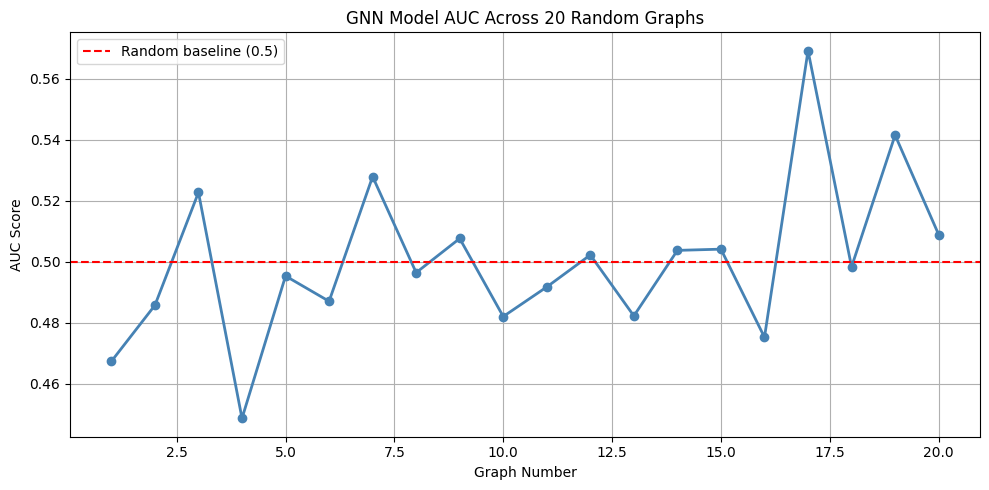

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

results = []

for i in range(20):
    num_rna  = 100
    num_ctcf = 50
    G = nx.bipartite.random_graph(num_rna, num_ctcf, p=0.05)
    edges = [(u, v - num_rna) for u, v in G.edges()
             if u < num_rna and v >= num_rna]
    if len(edges) < 4:
        continue
    src = torch.tensor([e[0] for e in edges], dtype=torch.long)
    dst = torch.tensor([e[1] for e in edges], dtype=torch.long)
    ei  = torch.stack([src, dst], dim=0)
    g_data = HeteroData()
    g_data['rna'].x  = torch.rand(num_rna, 128)
    g_data['ctcf'].x = torch.randn(num_ctcf, 128)
    g_data['rna', 'interacts', 'ctcf'].edge_index = ei
    auc = test(g_data)
    results.append({'Graph': i+1, 'Nodes': num_rna+num_ctcf,
                    'Edges': len(edges), 'AUC': round(auc, 4)})
    print(f"Graph {i+1:02d} | Nodes: {num_rna+num_ctcf} | Edges: {len(edges)} | AUC: {auc:.4f}")

df = pd.DataFrame(results)
print("\n--- Results Table ---")
print(df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(df['Graph'], df['AUC'], marker='o', color='steelblue', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='Random baseline (0.5)')
plt.xlabel('Graph Number')
plt.ylabel('AUC Score')
plt.title('GNN Model AUC Across 20 Random Graphs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()